In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import files

uploaded = files.upload()

Saving CarPrice_Assignment.csv to CarPrice_Assignment.csv


In [13]:
df = pd.read_csv("CarPrice_Assignment.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (205, 26)


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [15]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [16]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0





The dataset was checked for missing values, data types, and statistical summary.

In [21]:
#Data Preprocessing

X = df.drop("price", axis=1)
y = df["price"]

In [22]:
X = pd.get_dummies(X, drop_first=True)

print("Shape after Encoding:", X.shape)

Shape after Encoding: (205, 189)


In [25]:
#Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (164, 189)
Testing Set Shape: (41, 189)


In [26]:
#Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
#Linear regression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [29]:
#Decision Tree Regressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)


In [30]:
#Random Forest Regressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [31]:
#Gradient Boosting Regressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

In [32]:
#Support Vector Regressor (SVR)

svr = SVR()
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)

In [33]:
#Model Evaluation

results = []
models = {
    "Linear Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "SVR": svr_pred
}

for model_name, pred in models.items():

    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    mae = mean_absolute_error(y_test, pred)

    results.append([
        model_name,
        r2,
        mse,
        mae
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2 Score", "MSE", "MAE"]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,MSE,MAE
2,Random Forest,0.953457,3.674318e+06,1365.352512
3,Gradient Boosting,0.930597,5.478929e+06,1700.986585
1,Decision Tree,0.855898,1.137602e+07,2200.142268
0,Linear Regression,0.473715,4.154703e+07,4177.295631
4,SVR,-0.101709,8.697331e+07,5705.033285


Observation:

The performance of five regression models was evaluated using R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE).

Among all models, Random Forest Regressor achieved the highest R² Score of 0.9535 and the lowest prediction errors, making it the best-performing model.

Gradient Boosting Regressor also performed well with an R² Score of 0.9306.

Decision Tree Regressor showed moderate performance with an R² Score of 0.8559.

Linear Regression achieved a lower R² Score of 0.4737, indicating that the relationship between features and car prices is not purely linear.

Support Vector Regressor (SVR) produced a negative R² Score (-0.1017), indicating poor predictive performance on this dataset.

In [34]:
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]
print(best_model)

Model        Random Forest
R2 Score          0.953457
MSE         3674318.218352
MAE            1365.352512
Name: 2, dtype: object


## Best Performing Model

Among all the regression models tested, the Random Forest Regressor was identified as the best-performing model.

### Justification
The Random Forest Regressor achieved:

- R² Score = 0.953457
- Mean Squared Error (MSE) = 3,674,318.22
- Mean Absolute Error (MAE) = 1365.35

The model obtained the highest R² Score among all the models, indicating that it explained approximately 95.35% of the variation in car prices. It also produced the lowest MSE and MAE values, which means its predictions were closer to the actual car prices compared to the other models.

Random Forest performs well because it combines the predictions of multiple decision trees, reducing overfitting and improving generalization. This enables it to capture complex relationships between car features and price more effectively than Linear Regression, Decision Tree, Gradient Boosting, and Support Vector Regression.

Therefore, Random Forest Regressor was selected as the most suitable model for car price prediction.

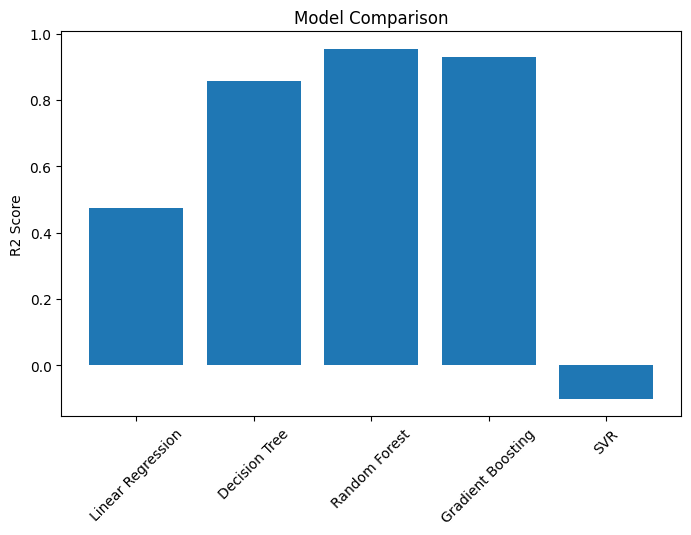

In [36]:
#Model Comparison Graph

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)
plt.xticks(rotation=45)
plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

In [37]:
#Feature Importance Analysis

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(10)

,Feature,Importance
6,enginesize,0.540808
5,curbweight,0.294927
13,highwaympg,0.043387
10,horsepower,0.038275
3,carwidth,0.013358
2,carlength,0.007710
12,citympg,0.006580
1,wheelbase,0.006204
11,peakrpm,0.005753
8,stroke,0.004195


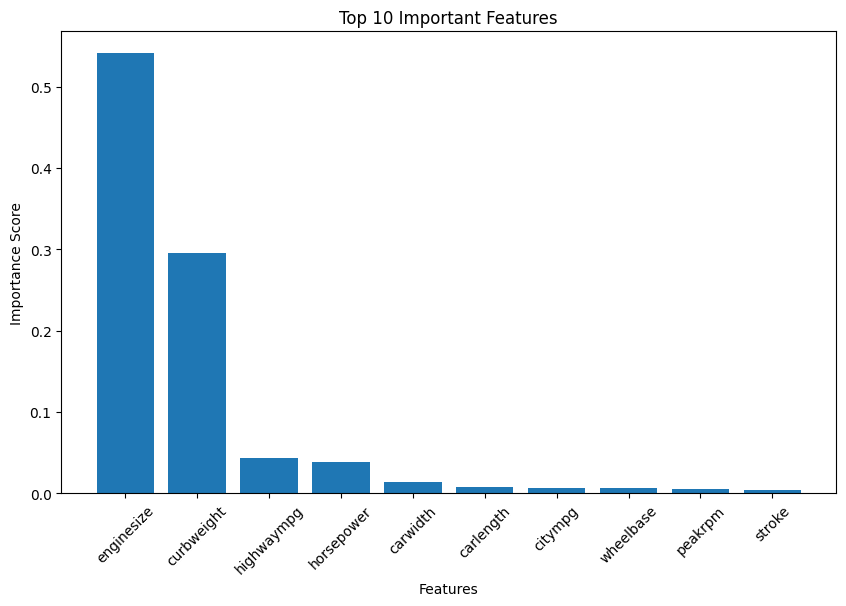

In [40]:
#Feature Importance Visualization

top10 = importance.head(10)
plt.figure(figsize=(10,6))
plt.bar(top10["Feature"], top10["Importance"])
plt.xticks(rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.title("Top 10 Important Features")
plt.show()



### Observation

The feature importance graph shows that Engine Size is the most influential factor affecting car prices, contributing approximately 54.08% of the total importance. Curb Weight is the second most important feature with an importance score of 29.49%.

Features such as Highway MPG and Horsepower also contribute to price prediction, whereas Wheelbase, Peak RPM, and Stroke have relatively lower influence. This indicates that engine performance and vehicle size play a major role in determining car prices.

In [42]:
#Hyperparameter Tuning

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

In [43]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [44]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


In [45]:
#Evaluate Tuned Model

best_rf = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test)
print("R2 Score:", r2_score(y_test, tuned_pred))
print("MSE:", mean_squared_error(y_test, tuned_pred))
print("MAE:", mean_absolute_error(y_test, tuned_pred))

R2 Score: 0.9556481400375855
MSE: 3501314.1589245056
MAE: 1333.2983417276732


## Performance Comparison After Hyperparameter Tuning

The performance of the Random Forest Regressor was compared before and after hyperparameter tuning.

- R² Score increased from 0.953457 to 0.955648.
- MSE decreased from 3,674,318.22 to 3,501,314.16.
- MAE decreased from 1365.35 to 1333.30.

The increase in R² Score and the reduction in both MSE and MAE indicate that the model's predictive performance improved after hyperparameter tuning.

Therefore, hyperparameter tuning successfully enhanced the accuracy and reliability of the Random Forest Regressor for car price prediction.